In [60]:
import nltk
import re
import pandas as pd

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [61]:
df=pd.read_csv("/content/Sentiment_Mental_health_dataset.csv")

In [62]:
df.head()

,statement,status
0,Anyone else have symptoms much improved after ...,Bipolar
1,"I basicaly do not exist, sure feels that way. ...",Suicidal
2,Finding a sense of self It's like one minute I...,Personality_disorder
3,Putting into words what were just tangles in m...,Anxiety
4,Anxiety makes me worry about my public image s...,Anxiety


In [63]:
df.shape

(26350, 2)

In [64]:
def processed_text(text):

    # If input is a single string (User Input)
    if isinstance(text, str):
        text = text.lower()

        text = re.sub(r'[^\x00-\x7F]+', '', text)
        # text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()

        tokens = word_tokenize(text)

        stop_words = set(stopwords.words('english')) - {'not', 'no', 'never'}
        tokens = [word for word in tokens if word not in stop_words]

        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

        return ' '.join(tokens)

    # If input is pandas Series (training)
    elif isinstance(text, pd.Series):

        text = text.str.lower()

        text = text.apply(lambda x: re.sub(r'[^\x00-\x7F]+', '', x))
        text = text.apply(lambda x: re.sub(r'[^\w\s]', '', x))
        text = text.apply(lambda x: re.sub(r'\s+', ' ', x).strip())

        text = text.apply(word_tokenize)

        stop_words = set(stopwords.words('english')) - {'not', 'no', 'never'}
        text = text.apply(lambda x: [word for word in x if word not in stop_words])

        lemmatizer = WordNetLemmatizer()
        text = text.apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

        return text.apply(lambda x: ' '.join(x))

    else:
        raise ValueError("Input must be either a string or pandas Series")
df["processed_text"] = processed_text(df["statement"])

In [65]:
print("Original:", df["statement"][1])
print("processed:", df["processed_text"][1])

Original: I basicaly do not exist, sure feels that way. No friends, no realtionships. I still got a family but they ignore and do not understand my condition. Suffering from social anxeity, depression, avoidance personality disorder since I was 15. I was in therapy for many years, took medication, and nothing. I had dreams, but I never pursued them, I just want to die and disappear.
processed: basicaly not exist sure feel way no friend no realtionships still got family ignore not understand condition suffering social anxeity depression avoidance personality disorder since 15 therapy many year took medication nothing dream never pursued want die disappear


In [66]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(df["status"])

In [67]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
df_mapping = pd.DataFrame(label_mapping.items(), columns=["Label", "Value"])
display(df_mapping)

,Label,Value
0,Anxiety,0
1,Bipolar,1
2,Depression,2
3,Normal,3
4,Personality_disorder,4
5,Stress,5
6,Suicidal,6


In [68]:
X = df["processed_text"]

In [69]:
df.to_csv("processed_dataset.csv", index=False)

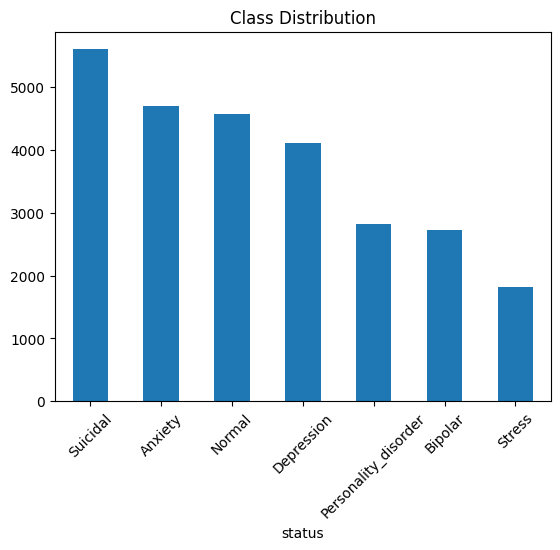

In [70]:
import matplotlib.pyplot as plt
df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=15000,ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

In [73]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [74]:
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (21080, 15000)
Test shape: (5270, 15000)


In [75]:
class_names = le.classes_

In [76]:
import pickle
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [77]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [78]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [79]:
svm_pred = svm_model.predict(X_test_tfidf)
rf_pred = rf_model.predict(X_test_tfidf)

In [80]:
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nSVM Report:\n", classification_report(y_test, svm_pred, target_names=class_names))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRF Report:\n", classification_report(y_test, rf_pred, target_names=class_names))

SVM Accuracy: 0.7597722960151803

SVM Report:
                       precision    recall  f1-score   support

             Anxiety       0.81      0.83      0.82       941
             Bipolar       0.82      0.71      0.76       544
          Depression       0.55      0.51      0.53       822
              Normal       0.95      0.98      0.97       915
Personality_disorder       0.80      0.73      0.76       563
              Stress       0.80      0.68      0.74       365
            Suicidal       0.66      0.77      0.71      1120

            accuracy                           0.76      5270
           macro avg       0.77      0.74      0.75      5270
        weighted avg       0.76      0.76      0.76      5270

Random Forest Accuracy: 0.7197343453510436

RF Report:
                       precision    recall  f1-score   support

             Anxiety       0.74      0.81      0.77       941
             Bipolar       0.86      0.65      0.74       544
          Depression     

In [81]:
results = pd.DataFrame({
    "Model": ["SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)]
})
print(results)

           Model  Accuracy
0            SVM  0.759772
1  Random Forest  0.719734


In [82]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(X_train_tfidf,y_train)

LogisticRegression()

In [83]:
lr_pred=lr_model.predict(X_test_tfidf)

In [84]:
print("LR Accuracy:", accuracy_score(y_test, lr_pred))

LR Accuracy: 0.7751423149905123


In [85]:
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("\nLR Report:\n", classification_report(y_test, lr_pred, target_names=class_names))

LR Accuracy: 0.7751423149905123

LR Report:
                       precision    recall  f1-score   support

             Anxiety       0.80      0.84      0.82       941
             Bipolar       0.87      0.69      0.77       544
          Depression       0.59      0.55      0.57       822
              Normal       0.96      0.98      0.97       915
Personality_disorder       0.86      0.71      0.78       563
              Stress       0.90      0.64      0.75       365
            Suicidal       0.66      0.83      0.73      1120

            accuracy                           0.78      5270
           macro avg       0.81      0.75      0.77      5270
        weighted avg       0.79      0.78      0.77      5270



In [86]:
from sklearn.model_selection import GridSearchCV
svm = LinearSVC()
param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"],
}
grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']},
             scoring='f1_weighted')

In [87]:
best_svm = grid_svm.best_estimator_
print("Best Params:", grid_svm.best_params_)

Best Params: {'C': 0.1, 'class_weight': 'balanced'}


In [88]:
svm_pred = best_svm.predict(X_test_tfidf)
print("Tuned SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nTuned SVM Report:\n", classification_report(y_test, svm_pred, target_names=class_names))

Tuned SVM Accuracy: 0.7834914611005692

Tuned SVM Report:
                       precision    recall  f1-score   support

             Anxiety       0.83      0.83      0.83       941
             Bipolar       0.82      0.74      0.78       544
          Depression       0.63      0.52      0.57       822
              Normal       0.94      0.99      0.96       915
Personality_disorder       0.81      0.76      0.78       563
              Stress       0.76      0.76      0.76       365
            Suicidal       0.69      0.81      0.75      1120

            accuracy                           0.78      5270
           macro avg       0.78      0.77      0.78      5270
        weighted avg       0.78      0.78      0.78      5270



In [89]:
lr = LogisticRegression(max_iter=1000)
param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"]}
grid_lr = GridSearchCV(lr,param_grid,cv=3,scoring="f1_weighted",n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']},
             scoring='f1_weighted')

In [90]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'class_weight': 'balanced'}
Best CV Score: 0.7653078622048856


In [91]:
best_lr = grid_lr.best_estimator_

In [92]:
lr_pred = best_lr.predict(X_test_tfidf)

In [93]:
print("\nTuned Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nTuned Logistic Regression Report:\n", classification_report(y_test, lr_pred, target_names=class_names))


Tuned Logistic Regression Accuracy: 0.7755218216318785

Tuned Logistic Regression Report:
                       precision    recall  f1-score   support

             Anxiety       0.85      0.80      0.83       941
             Bipolar       0.80      0.74      0.77       544
          Depression       0.57      0.58      0.58       822
              Normal       0.95      0.98      0.96       915
Personality_disorder       0.80      0.75      0.78       563
              Stress       0.73      0.79      0.76       365
            Suicidal       0.72      0.75      0.74      1120

            accuracy                           0.78      5270
           macro avg       0.77      0.77      0.77      5270
        weighted avg       0.78      0.78      0.78      5270



In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

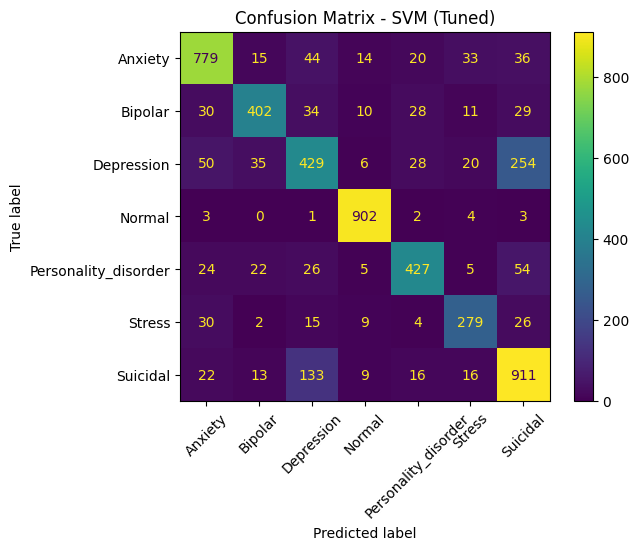

In [95]:
cm_svm = confusion_matrix(y_test, svm_pred)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=le.classes_
)

disp_svm.plot(xticks_rotation=45)
plt.title("Confusion Matrix - SVM (Tuned)")
plt.show()

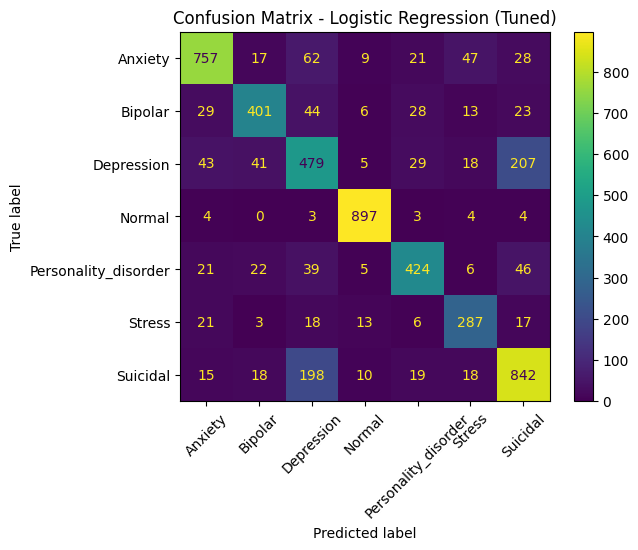

In [96]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=le.classes_
)

disp_lr.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression (Tuned)")
plt.show()

In [97]:
def predict_text(text):
    processed = processed_text(text)
    vector = tfidf.transform([processed])
    pred = grid_lr.best_estimator_.predict(vector)
    label = le.inverse_transform(pred)
    return label[0]

In [98]:
text = " I feel like I'm sinking in a crowded room, desperately gasping for air while pretending that everything is perfectly fine when it isn't.."
print("Enter Text:",text)
print("Sentiment Prediction:", predict_text(text))

Enter Text:  I feel like I'm sinking in a crowded room, desperately gasping for air while pretending that everything is perfectly fine when it isn't..
Sentiment Prediction: Depression


In [99]:
import pickle

# Save Final Logistic Regression Model
with open("lr_model.pkl", "wb") as f:
    pickle.dump(grid_lr.best_estimator_, f)

# Save TF-IDF Vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save Label Encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("All files saved successfully!")

All files saved successfully!
